## Install cuda 12.3 first

In [ ]:
!wget https://developer.download.nvidia.com/compute/cuda/12.3.0/local_installers/cuda-repo-ubuntu2204-12-3-local_12.3.0-545.23.06-1_amd64.deb
!dpkg -i cuda-repo-ubuntu2204-12-3-local_12.3.0-545.23.06-1_amd64.deb
!cp /var/cuda-repo-ubuntu2204-12-3-local/cuda-*-keyring.gpg /usr/share/keyrings/
!apt-get update
!apt-get -y install cuda-12-3

# Set environment variables
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.3'
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-12.3/lib64:$LD_LIBRARY_PATH'
os.environ['PATH'] = '/usr/local/cuda-12.3/bin:' + os.environ.get('PATH', '')

## Prepare all dependencies

**Add access of the folder to MyDrive**

In [ ]:
!cp "/content/drive/MyDrive/cutLPK_Experiments/Dependency Lib/kmeans_cupdlp.tar.gz" .
!tar -xvf kmeans_cupdlp.tar.gz

In [ ]:
!cp "/content/drive/MyDrive/cutLPK_Experiments/Dependency Lib/HiGHS.tar.gz" .
!tar -xvf HiGHS.tar.gz

In [ ]:
!cp "/content/drive/MyDrive/cutLPK_Experiments/Dependency Lib/eigen.tar.gz" .
!tar -xvf eigen.tar.gz

In [ ]:
!cp "/content/drive/MyDrive/cutLPK_Experiments/Dependency Lib/gurobi11.0.2_linux64.tar.gz" .
!tar -xvf gurobi11.0.2_linux64.tar.gz

In [ ]:
import os
os.environ['LD_LIBRARY_PATH'] = f"{os.environ.get('LD_LIBRARY_PATH', '')}:/content/kmeans_cupdlp/out/build/linux-release-CUDA/lib"
!echo $LD_LIBRARY_PATH

/usr/local/cuda-12.3/lib64:$LD_LIBRARY_PATH:/content/kmeans_cupdlp/out/build/linux-release-CUDA/lib


In [ ]:
!cp "/content/drive/MyDrive/cutLPK_Experiments/Dependency Lib/cutLPK.tar.gz" .
!tar -xvf cutLPK.tar.gz

**Rebuilding**

In [ ]:
%cd /content/cutLPK
!mkdir build
%cd build
!rm CMakeCache.txt
!cmake ..
!make

## Example usage

In [ ]:
%cd /content/cutLPK/build

In [ ]:
!./cutLPK iris.csv 3

Running ordinary clustering with K = 3
Lloyd objective: 78.9408
Initial cuts size: 932856
                                     ITERATIVE CUTTING PLANE
      Iter          LB          UB         Gap     T      Active    Violated       Total   Solver(s)    Total(s)
-------------------------------------------------------------------------------------------------------------------
         1   7.894e+01   7.894e+01     0.00000     2           0           0      932856       8.274       8.278
cutLPK return code: 0
Lloyd objective: 78.9
Final lower bound: 78.9
Final upper bound: 78.9
Final Optimality Gap: 1.66e-06


**change WLS license in folder build!!!!!!**

In [ ]:
!./cutLPK HC_data.csv 3 fairness_type=alpha group_file=HC_labels.csv fairness_param=0.99

Running fair clustering with K = 3 and fairness type: alpha
numGroups: 2
dataPoints size: 297
Initial cuts size: 7235045
Fair Lloyd objective: 4200.3
                                     ITERATIVE CUTTING PLANE
      Iter          LB          UB         Gap     T      Active    Violated       Total   Solver(s)    Total(s)
-------------------------------------------------------------------------------------------------------------------
+        1   4.171e+03   4.200e+03     0.00689     3     4020415       14483     4034898     190.949     194.815
         2   4.183e+03   4.200e+03     0.00412     3     4004304       37451     4041755     185.404     382.967
         3   4.186e+03   4.200e+03     0.00346     3     3705296       43170     3748466     186.355     572.785
         4   4.187e+03   4.200e+03     0.00308     3     3644480       64793     3709273     184.991     760.226
         5   4.187e+03   4.200e+03     0.00305     3     3554608       50397     3605005     184.956     947

In [40]:
!./cutLPK football_L.csv 7 is_spectral_clustering=true

Running spectral clustering with K = 7
Spectral heuristic completed with objective: 19.2604
Initial cuts size: 200271
                                     ITERATIVE CUTTING PLANE
      Iter          LB          UB         Gap     T      Active    Violated       Total   Solver(s)    Total(s)
-------------------------------------------------------------------------------------------------------------------
         1   1.835e+01   1.926e+01     0.04723     2      141613         823      142436       2.675       2.778
         2   1.859e+01   1.907e+01     0.02499     2      140398        2271      142669       4.585       7.445
+        3   1.862e+01   1.890e+01     0.01502     3      141853         306      142159       1.679       9.205
         4   1.862e+01   1.890e+01     0.01483     3      142088         540      142628       2.170      11.458
         5   1.875e+01   1.890e+01     0.00823     3      140693        1745      142438      26.574      38.120
         6   1.880e+01   1.

## Plot gap vs time curve

In [ ]:
import re

def read_cutting_plane_log(filepath):
    data = []
    transition_iters = []

    prev_T = None
    with open(filepath, 'r') as f:
        for idx, line in enumerate(f):
            # Matches line with iteration and columns: Iter, LB, UB, Gap, T, ..., Total(s)
            match = re.search(
                r"\s*\D*(\d+)\s+([\d.eE+\-]+)\s+([\d.eE+\-]+)\s+([\d.eE+\-]+)\s+(\d+)\s+\d+\s+\d+\s+\d+\s+[\d.eE+\-]+\s+([\d.eE+\-]+)",
                line)
            if match:
                iter_num = int(match.group(1))
                gap = float(match.group(4))
                T_val = int(match.group(5))
                total_time = float(match.group(6))

                data.append((total_time, gap, T_val))

                if prev_T is None:
                    prev_T = T_val
                    if T_val != 2:
                        transition_iters.append(iter_num - 1)
                elif T_val > prev_T:
                    transition_iters.append(iter_num - 1)
                    prev_T = T_val

    return data, transition_iters



In [ ]:
import matplotlib.pyplot as plt

def plot_gap_vs_time(datasets, legend_control=None, T_markers=None):
    plt.figure(figsize=(6, 5))

    for label, data in datasets:
        times = [t for t, _, _ in data]
        gaps = [g for _, g, _ in data]

        style = legend_control.get(label, {}) if legend_control else {}
        plt.plot(times, gaps,
                 label=label,
                 color=style.get('color', None),
                 marker=style.get('marker', None),
                 linestyle=style.get('linestyle', '-'),
                 markersize=6)

        if T_markers and label in T_markers:
            for idx in T_markers[label]:
                if 0 <= idx < len(data):
                    t_val, gap_val, _ = data[idx]
                    plt.scatter(t_val, gap_val,
                                marker='h',
                                s=100,
                                color='y',
                                zorder=5,
                                label=f"t increased" if idx == T_markers[label][0] else "")

    plt.xlabel("Elapsed Time (s)", fontsize=14, fontweight='bold')
    plt.ylabel("Optimality Gap", fontsize=14, fontweight='bold')
    plt.grid(False)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

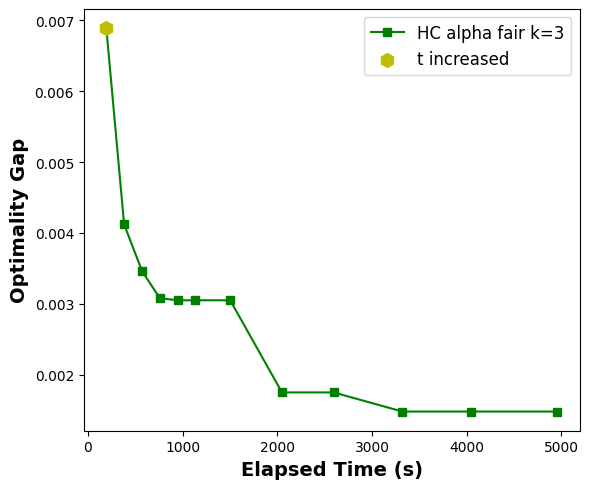

In [ ]:
#run1_data, run1_transitions = read_cutting_plane_log("iris.csv_K3_output.txt")
run2_data, run2_transitions = read_cutting_plane_log("HC_data.csv_K3_alpha_output.txt")

datasets = [
#    ("iris ordinary k=3", run1_data),
    ("HC alpha fair k=3", run2_data)
]

legend_control = {
    "iris k=3": {'color': 'b', 'marker': 'o', 'linestyle': '-'},
    "HC alpha fair k=3": {'color': 'g', 'marker': 's', 'linestyle': '-'}
}

t_markers = {
#    "iris k=3": run1_transitions,
    "HC alpha fair k=3": run2_transitions
}

plot_gap_vs_time(datasets, legend_control, T_markers=t_markers)